# Segmentation

**In this lecture, we will learn**
- basics of image segmentation,
- automatic and adaptive thresholding,
- what superpixels are and how they can be extracted,
- morphological watershed segmentation,
- graph-based image segmentation using minimum cuts and GrabCut,
- and modern deep-learning-based segmentation using Segment Anything Model 2 (SM2).

**The lecture is based on**
- Chapter 10 "Image Segmentation" of  
  [\[Gonzalez18\] Rafael C. Gonzalez, Richard E. Woods. *Digital Image Processing (4th edition)*](https://www.imageprocessingplace.com/)
- OpenCV documentation  
  https://docs.opencv.org/4.x/d8/d83/tutorial_py_grabcut.html

In [1]:
import heapq
import os
from typing import Literal

import cv2 as cv
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sam2.build_sam
import sam2.sam2_image_predictor
import scipy
import seaborn as sns
import skimage
import sklearn

In [2]:
plt.rcParams['figure.constrained_layout.use'] = True
np.set_printoptions(threshold=20, edgeitems=10, linewidth=140, precision=3, suppress=True, formatter={'bool': lambda x: str(int(x))})

In [3]:
def imshow_grid(
    nrows: int | None = None,
    ncols: int | None = None,
    figsize: tuple[float, float] | None = None,
    cmap: str = 'gray',
    vmin: int | float | Literal['min'] = 0,
    vmax: int | float | Literal['dtype', 'max'] = 'dtype',
    grid: bool = False,
    colorbar: bool = True,
    interpolation: Literal['nearest', 'bilinear'] = 'bilinear',
    axis_off: bool = True,
    proportional: bool = False,
    **images,
) -> tuple[plt.Figure, np.ndarray]:
    if nrows is None:
        nrows = 1
    if ncols is None:
        ncols = -int(-len(images) // nrows)  # ceil
    if figsize is None:
        fig_size_y = nrows * plt.rcParams['figure.figsize'][1]
        fig_size_x = max(1, (ncols + 1) / 2) * plt.rcParams['figure.figsize'][0]
    else:
        fig_size_x, fig_size_y = figsize
    if proportional:
        if nrows > 1:
            raise ValueError
        gridspec_kw = {'width_ratios': [img.shape[1] for img in images.values()]}
    else:
        gridspec_kw = None
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_size_x, fig_size_y), layout='constrained', gridspec_kw=gridspec_kw)
    axes = np.atleast_1d(axes)
    im = None
    rgb_only = True
    for ax, (name, img) in zip(axes.flat, images.items()):
        _vmin = vmin
        if _vmin == 'min':
            _vmin = img.min()
        _vmax = vmax
        if _vmax == 'dtype':
            _vmax = np.iinfo(img.dtype).max if np.issubdtype(img.dtype, np.integer) else 1.0
        elif _vmax == 'max':
            _vmax = img.max()
        im = ax.imshow(img, cmap=cmap, vmin=_vmin, vmax=_vmax, interpolation=interpolation)
        ax.grid(grid)
        ax.set_title(name)
        if axis_off:
            ax.axis('off')
        if img.ndim < 3 or img.shape[2] != 3:
            rgb_only = False
    if colorbar and im is not None and not rgb_only:
        if ncols > nrows:
            orientation = 'horizontal'
        elif ncols == nrows:
            orientation = 'horizontal' if im.get_size()[1] > im.get_size()[0] else 'vertical'
        else:
            orientation = 'vertical'
        if vmin == 'min' or vmax == 'max':
            for ax in axes.flat[: len(images)]:
                fig.colorbar(ax.images[0], ax=ax, orientation=orientation, aspect=30)
        else:
            fig.colorbar(im, ax=axes, orientation=orientation, aspect=50)
    return fig, axes

In [4]:
def label2rgb(
    label: np.ndarray,
    image: np.ndarray | None = None,
    bg_label: int = 0,
    bnd_color=(1.0, 1.0, 1.0),
    alpha: float = 0.2,
) -> np.ndarray:
    if alpha > 0 or image is None:
        rgb = skimage.color.label2rgb(label, image=image, alpha=alpha, bg_label=bg_label)
    else:
        rgb = image.copy()
    rgb = skimage.segmentation.mark_boundaries(rgb, label, color=bnd_color, mode='inner')
    return rgb

# Thresholding

- Thresholding can be viewed as an image segmentation technique, in which we classify each pixel as either foreground or background.
- It can also be viewed as a special case of *semantic segmentation*, which is a task to assign each pixel of an image to one of predefined classes, e.g. {bg, fg} or {0, 1}.
- The rule of classification is  
  $$
  S(m, n) = \begin{cases}
    0 & \text{if} \quad I(m, n) \lt t \\
    1 & \text{if} \quad I(m, n) \ge t
  \end{cases}
  $$
  where
  - $I$ is the input image,
  - $t$ is some threshold value,
  - $S$ is the output segmentation of I (called `labels` in the lecture's code).

In [5]:
coins_rgb = skimage.io.imread('../data/coins.png')
coins_gray = skimage.util.img_as_ubyte(skimage.color.rgb2gray(coins_rgb))
coins_gray.shape, coins_gray.dtype, coins_gray.min(), coins_gray.max()

((480, 640), dtype('uint8'), np.uint8(44), np.uint8(234))

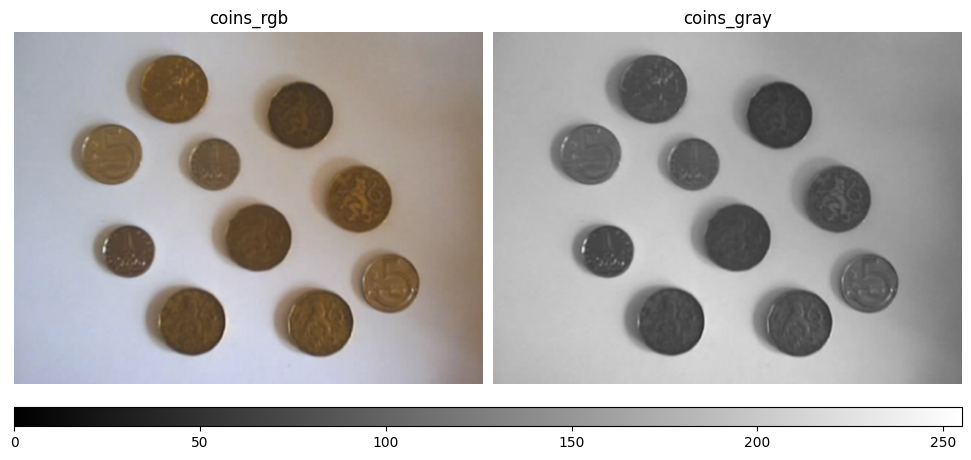

In [6]:
imshow_grid(coins_rgb=coins_rgb, coins_gray=coins_gray);

In [7]:
coins_labels_thr = (coins_gray < 0.5).astype(np.int32)
coins_labels_thr

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 

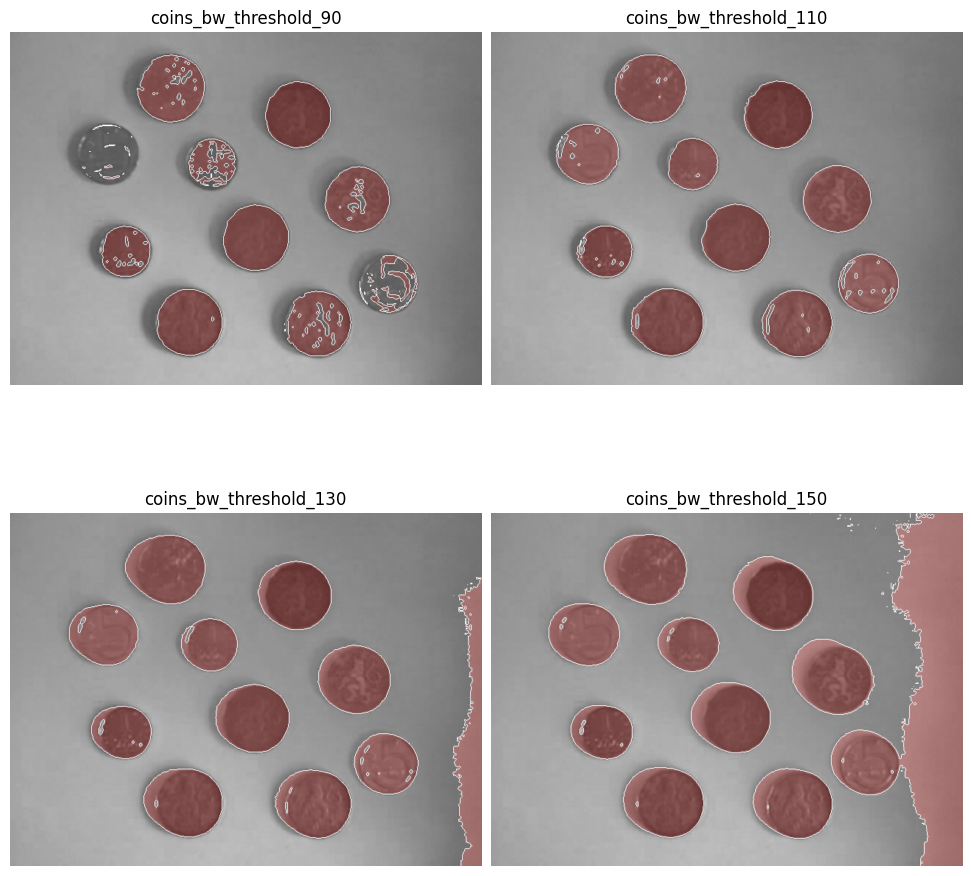

In [8]:
imshow_grid(2, 2, **{f'coins_bw_threshold_{t}': label2rgb(coins_gray < t, coins_rgb) for t in (90, 110, 130, 150)});

## Automatic threshold selection using the Otsu's method

- Previsouly, we hand-picked the threshold value by trial and error with manual and subjective evaluation of segmentation quality.
- We can create an objective criterion and automate the threshold selection using Otsu's method.
- Its idea is illustrated in the figure below.

<figure class="image">
  <img src="../figures/segmentation-otsu.svg" alt="" style="width: 12.8in; background: white"/>
  <figcaption>
    Within-class and between-class variances for Otsu's threshold selection method.
  </figcaption>
</figure>

**Summary of the algorithm**
- Consider an image that has well-separated foreground and background.
- Such image will have a bi-modal histogram (i.e. two "blobs") as in the figure above.
- When we threshold the image, we're essentially splitting the histogram into left and right parts, corresponding to background and foreground pixels, respectively.
- Intuitively, we want to pick the threshold value so that the two blobs are nicely separated.
- But how exactly should we measure the "niceness"? Otsu suggests one of two ways (both are in fact equivalent):
  1) **Within-class (intra-class) variance**
     - Calculate the *variance* of each part and pick the threshold that *minimizes their weighted sum*.
     - In other words, pick the threshold so that both blobs are *as narrow as possible*.
  2) **Between-class (inter-class) variance**
     - Calculate the *mean (expected value)* of each part and pick the threshold that *maximizes their weighted distance*.
     - In other words, we want the blobs' "centers of gravity" to be as far apart as possible.

**Details**
- The number (proportion) of pixels $w_0(t)$ and $w_1(t)$ assigned to the *background* class and *foreground* class, respectively, by the threshold $t$ can be determined from the histogram $h$ as
$$
w_0(t) = \sum_{v=0}^{t-1}h(v) \qquad\qquad w_1(t) = \sum_{v=t}^{255}h(v)
$$
- Now, we can compute expected values (average) $\mu_0$ and $\mu_1$ and variances $\sigma_0^2$ and $\sigma_1^2$ of the *background* and *foreground* classes, respectively
$$
\begin{align*}
  \mu_0(t) & = \sum_{v=0}^{t-1}{v \cdot \frac{h(v)}{w_0(t)}} \qquad\qquad & \mu_1(t) & = \sum_{v=t}^{255}{v \cdot \frac{h(v)}{w_1(t)}} \\
  \sigma_0^2(t) & = \sum_{v=0}^{t-1}{(v - \mu_0(t))^2 \cdot \frac{h(v)}{w_0(t)}} \qquad\qquad & \sigma_1^2(t) & = \sum_{v=t}^{255}{(v - \mu_1(t))^2 \cdot \frac{h(v)}{w_1(t)}} \\
\end{align*}
$$
- The **within-class (intra-class) variance** $\sigma_w^2$ is a weighted average of variances of the two PMFs (probability mass functions, i.e. normalized left and right parts of the histogram), i.e.  
  $$
  \sigma_w^2(t) = w_0(t) \cdot \sigma_0^2(t) + w_1(t) \cdot \sigma_1^2(t)
  $$
- The **between-class (inter-class) variance** $\sigma_b^2$ is a squared difference between the PMFs expected values, i.e.  
  $$
  \sigma_b^2(t) = w_0(t) \cdot w_1(t) \cdot \left(\mu_0(t) - \mu_1(t) \right)^2
  $$
- We will compute $\sigma_w^2(t)$ and/or $\sigma_b^2(t)$ for each $t = 1, \ldots, 255$. Our desired optimal threshold $t^*$ is the one that
  - *minimizes*, i.e. makes the $\sigma_w^2(t^*)$ smallest, i.e. $t^* = \argmin_{t}{\sigma_w^2(t)}$
  - *maximizes*, i.e. makes the $\sigma_b^2(t^*)$ largest, i.e. $t^* = \argmax_{t}{\sigma_b^2(t)}$

In [9]:
coins_hist, coins_bins = np.histogram(coins_gray.ravel(), bins=np.arange(257))
coins_hist = coins_hist.ravel() / coins_hist.sum()  # make it PMF
coins_hist.shape, coins_hist.dtype, coins_hist.min(), coins_hist.max()

((256,), dtype('float64'), np.float64(0.0), np.float64(0.018388671875))

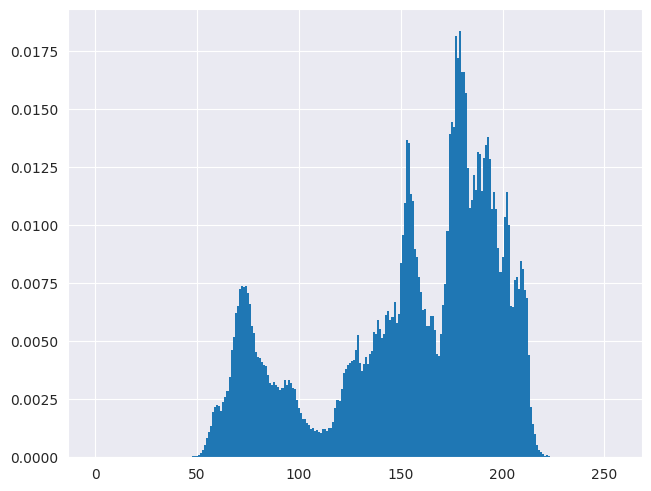

In [10]:
with sns.axes_style('darkgrid'):
    plt.bar(coins_bins[:256], coins_hist, width=1.0, edgecolor='none');

In [11]:
def otsu_threshold(hist: np.ndarray, method: str = 'within_var_min') -> tuple[int, np.ndarray]:
    # initialization
    if method == 'within_var_min':
        var = np.inf * np.ones(255)
    elif method == 'between_var_max':
        var = np.zeros(255)
    else:
        raise ValueError

    # exhaustively for each possible threshold
    for t in range(1, 255):
        # sums of background and foreground pixels proportions
        w0 = hist[:t].sum()
        w1 = hist[t:].sum()
        
        # prevent division by zero
        if w0 < 1e-5 or w1 < 1e-5:
            continue
        
        # calculate the means
        m0 = np.sum(np.arange(t) * hist[:t]) / w0
        m1 = np.sum(np.arange(t, 256) * hist[t:]) / w1
        
        # variances
        v0 = np.sum(hist[:t] * (np.arange(t) - m0) ** 2) / w0
        v1 = np.sum(hist[t:] * (np.arange(t, 256) - m1) ** 2) / w1
        
        if method == 'within_var_min':
            var[t] = w0 * v0 + w1 * v1  # intra-class variance
        elif method == 'between_var_max':
            var[t] = w0 * w1 * (m0 - m1) ** 2  # inter-class variance
    
    thr = var.argmin().item() if method == 'within_var_min' else var.argmax().item()
    return thr, var

In [12]:
thr_within, var_within = otsu_threshold(coins_hist, method='within_var_min')
thr_between, var_between = otsu_threshold(coins_hist, method='between_var_max')
thr_within, thr_between  # should be the same

(135, 135)

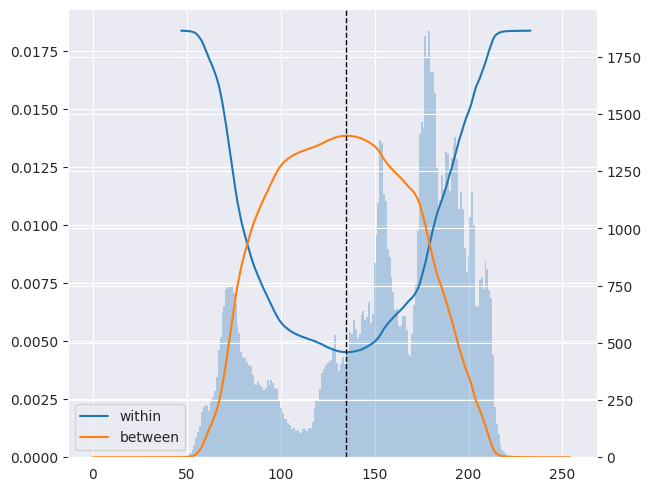

In [13]:
with sns.axes_style('darkgrid'):
    plt.bar(coins_bins[:256], coins_hist, width=1., edgecolor='none', alpha=0.3);
    plt.gca().twinx()
    plt.plot(var_within, label='within');
    plt.plot(var_between, label='between');
    plt.ylim(bottom=0)
    plt.axvline(x=thr_within, linestyle='--', linewidth=1, color='k')
    plt.legend();

In [14]:
# threhold using automatically selected value
coins_bw = coins_gray < thr_within

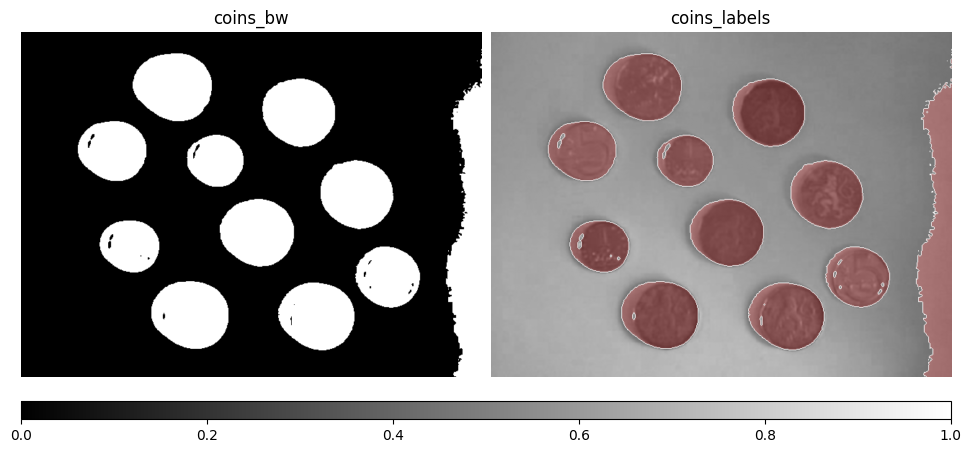

In [15]:
imshow_grid(coins_bw=coins_bw, coins_labels=label2rgb(coins_bw, coins_rgb));

## Adaptive thresholding using Niblack's method

- Otsu's thresholding as described above is an example of *global thresholding*, because we use constant threshold value to separate foreground and background.
- This will obviously break when the scene is captured under non-uniform lighting conditions.
- We already saw one way of dealing with this: morphological top-hat.
- Another way is to use *different threshold values for different parts of the image*.
- Techniques that process each part of the image in a different way are usually called *adaptive*.

**Niblack's method**
- The threshold is recomputed for each pixel of the image, i.e. each pixel is thresholded against a different value.
1. Take a small neigborhood around each pixel $(m, n)$. Recommended is 31x31 pixels.
2. Calcuate the mean value $\mu(m ,n)$ and standard deviation $\sigma(m, n)$.
3. The threshold value for that pixel is  
   $$
   t(m, n) = \mu(m, n) + \kappa \cdot \sigma(m, n) + c
   $$
   where
   - recommended $\kappa = \pm 0.18$ (plus or minus depending on whether we threshold bright or dark objects),
   - $c$ is some constant to prevent ghosting in flat regions due to noise.

<!-- **Sauvola's method**
- Sauvola and Pietikäinen proposed to set the threshold value to  
  $$
  t(m, n) = \mu(m, n) \cdot \left( 1 - \kappa \cdot \left( \frac{\sigma(m, n)}{\sigma_\text{max}} - 1 \right) \right)
  $$
  where
  - $\kappa = 0.5$,
  - $\sigma_\text{max} = 128$ for uint8 images.
- This means that
  - threshold depends not only on local variation but also on the local mean,
  - which means that changes in overall brightness cause different values of the threshold. -->

<figure class="image">
  <img src="../figures/segmentation-niblack.png" alt="" style="width: 6.4in; background: white"/>
  <figcaption>
    Adaptive tresholding principle.<br>
    Source: [Burger22], Fig. 9.11
  </figcaption>
</figure>

In [16]:
def niblack_threshold(
    image: np.ndarray,
    window_size: int = 31,
    k: float = 0.18,
    c: float = 0.0,
) -> np.ndarray:
    # compute local mean and local standard deviation
    averaging_kernel = np.ones((window_size, window_size)) / (window_size ** 2)
    mean = scipy.ndimage.convolve(image.astype(np.float64), averaging_kernel)
    mean_of_squares = scipy.ndimage.convolve(image.astype(np.float64) ** 2, averaging_kernel)
    std = np.sqrt(mean_of_squares - mean ** 2)
    
    # compute Niblack's threshold
    thr = mean + k * std + c
    return thr

In [17]:
rice_gray = skimage.util.img_as_ubyte(skimage.io.imread('../data/rice.png', as_gray=True))
rice_gray.shape, rice_gray.dtype, rice_gray.min(), rice_gray.max()

((256, 256), dtype('uint8'), np.uint8(25), np.uint8(213))

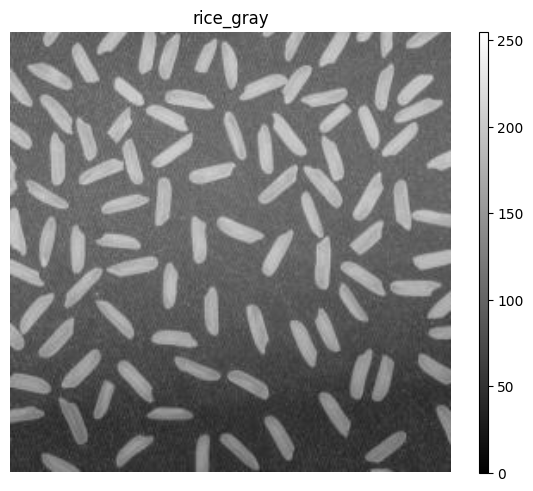

In [18]:
imshow_grid(rice_gray=rice_gray);

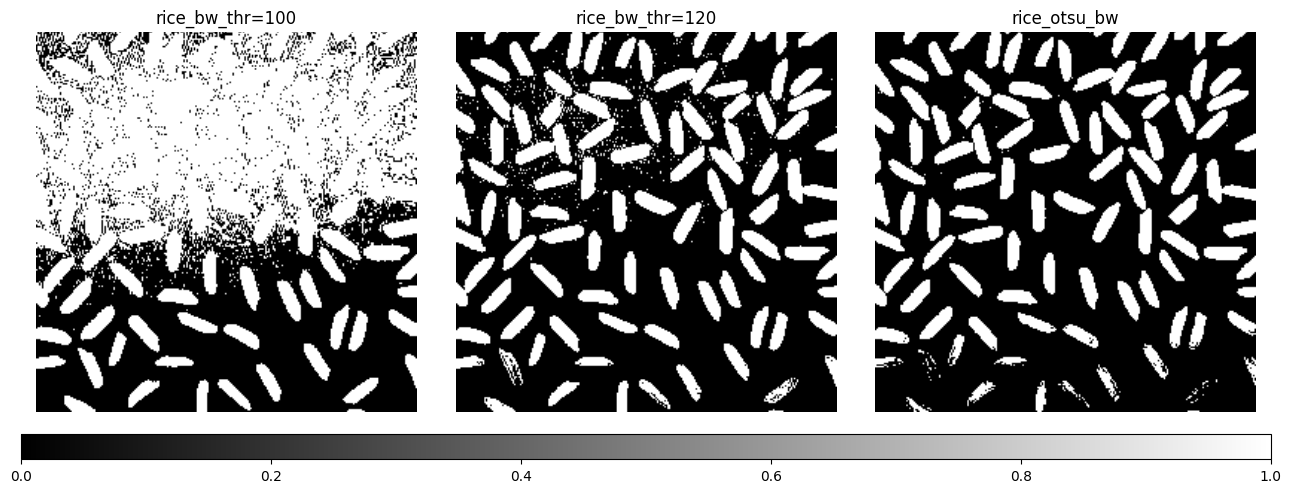

In [19]:
# Try global thresholding against various values
# See that there is no single good threshold value separating rice grains from background
rice_otsu_thr = otsu_threshold(np.histogram(rice_gray.ravel(), bins=np.arange(257))[0])[0]
imshow_grid(**{f'rice_bw_thr={t}': rice_gray >= t for t in (100, 120)}, rice_otsu_bw=rice_gray >= rice_otsu_thr);

In [20]:
# Now try adaptive thresholding using Niblack's method
rice_niblack_thr = niblack_threshold(rice_gray, window_size=31, c=20.0)
rice_niblack_thr.shape, rice_niblack_thr.dtype, rice_niblack_thr.min(), rice_niblack_thr.max()

((256, 256),
 dtype('float64'),
 np.float64(72.99414661071782),
 np.float64(178.02662996894963))

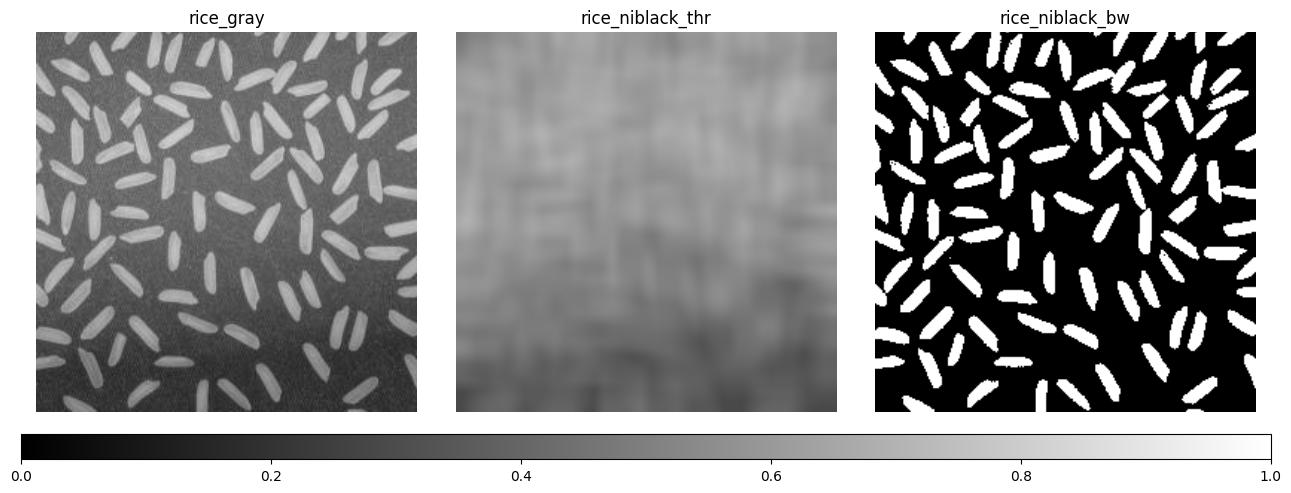

In [21]:
imshow_grid(rice_gray=rice_gray, rice_niblack_thr=rice_niblack_thr.astype(np.uint8), rice_niblack_bw=rice_gray >= rice_niblack_thr);

# Superpixels segmentation

- A superpixel is a small, contiguous cluster of pixels that are similar in appearance (e.g., color, brightness, texture).
- Properties:
  1. They partition the image (no overlaps, no gaps)
  2. Regions are locally homogeneous (similar colors/textures)
  3. Regions are compact (roughly similar size/shape)
  4. Boundaries adhere to important edges in the underlying image
- Superpixels reduce computation and add structure:
  - Compress image from millions of pixels to ~1000 regions.
  - Useful for object recognition, semantic segmentation, depth estimation, optical flow, medical imaging, interactive segmentation (e.g., GrabCut improvements), etc.

<figure class="image">
  <img src="../figures/segmentation-superpixels_example.png" alt="" style="width: 9.6in; background: white"/>
  <figcaption>
    Example of superpixel segmentation.<br>
    Source: <a>https://docs.opencv.org/4.x/df/d6c/group__ximgproc__superpixel.html</a>
  </figcaption>
</figure>

## Simple Linear Iterative Clustering (SLIC)

- SLIC is a popular algorithm used in computer vision to generate superpixels.
- SLIC adapts [**k-means clustering**](https://en.wikipedia.org/wiki/K-means_clustering) for image segmentation and it works in a 5-dimensional space:
  - **L, a, b** (from the CIELAB color space)  
  - **x, y** (pixel coordinates)
- This means each pixel is treated as a point  
  $$
  \bold{x} = [L, a, b, x, y]^\top
  $$
- SLIC finds clusters in this space to form compact, visually coherent superpixels.


**How SLIC Works**
1. Initialization
   - Choose how many superpixels you want ($K$) or the approximate size.
   - The image is divided into a grid, and an initial cluster center is placed in each cell.
   - Each cluster center contains:
     - color values $(L, a, b)$
     - spatial location $(x, y)$
2. Local Search
   - Unlike standard k-means, which compares each point to every cluster, SLIC restricts the search to a *small region* around each center (size ~ 2S × 2S, where S = grid    interval). This makes SLIC very fast.
3. Distance Measure
- SLIC uses a combined distance metric  
  $$
  D = \sqrt{d_c^2 + \left( \frac{m}{S} \right)^2 d_s^2}
  $$
  where
  - $d_c$ is color distance in LAB,
  - $d_s$ is spatial distance,
  - $m$ is compactness hyperparameter,
  - $S$ is grid interval.
  - Effect of compactness $m$
    - low $m$ → superpixels follow object boundaries closely  
    - high $m$ → superpixels become more square and compact.
4. Assignment
   - Each pixel in the search region is assigned to the nearest cluster center based on $D$.
5. Update
   - Cluster centers are updated to be the mean of all assigned pixels.
6. Convergence
   - Steps 2–5 are repeated until cluster movement becomes minimal.
7. Postprocessing
   - A final cleanup ensures all superpixels are connected (removes stray pixels).

<figure class="image">
  <img src="../figures/segmentation-kmeans.gif" alt="" style="width: 6.4in; background: white"/>
  <figcaption>
    K-Means convergence.<br>
    Source: <a>https://en.wikipedia.org/wiki/K-means_clustering</a>
  </figcaption>
</figure>

In [22]:
def slic_with_kmeans(
    img: np.ndarray,
    n_segments: int = 200,
    compactness: float = 10.0,
    max_iter: int = 20,
) -> np.ndarray:
    H, W = img.shape[:2]
    N = H * W

    img = skimage.util.img_as_float64(img)

    # Convert to LAB
    lab = skimage.color.rgb2lab(img)
    L = lab[..., 0].reshape(-1)
    a = lab[..., 1].reshape(-1)
    b = lab[..., 2].reshape(-1)

    # Make XY coordinate features
    ys, xs = np.indices((H, W))
    ys = ys.reshape(-1)
    xs = xs.reshape(-1)

    # Feature scaling
    #
    # SLIC distance:
    #   sqrt(dc^2 + (m/S)^2 ds^2)
    #
    # KMeans = pure Euclidean -> scale XY relative to LAB
    #
    S = np.sqrt(N / n_segments)  # grid interval
    xy_scale = compactness / S  # equivalent XY multiplier

    features = np.column_stack([L, a, b, xs * xy_scale, ys * xy_scale])

    # Run KMeans in LABXY space
    kmeans = sklearn.cluster.KMeans(n_clusters=n_segments, n_init=1, max_iter=max_iter, verbose=0).fit(features)

    # Reshape labels back to image grid
    labels = kmeans.labels_.reshape(H, W)

    return labels

In [23]:
fruit_rgb = skimage.io.imread('../data/fruits.jpg')
fruit_labels = slic_with_kmeans(fruit_rgb, n_segments=200, compactness=30.0)

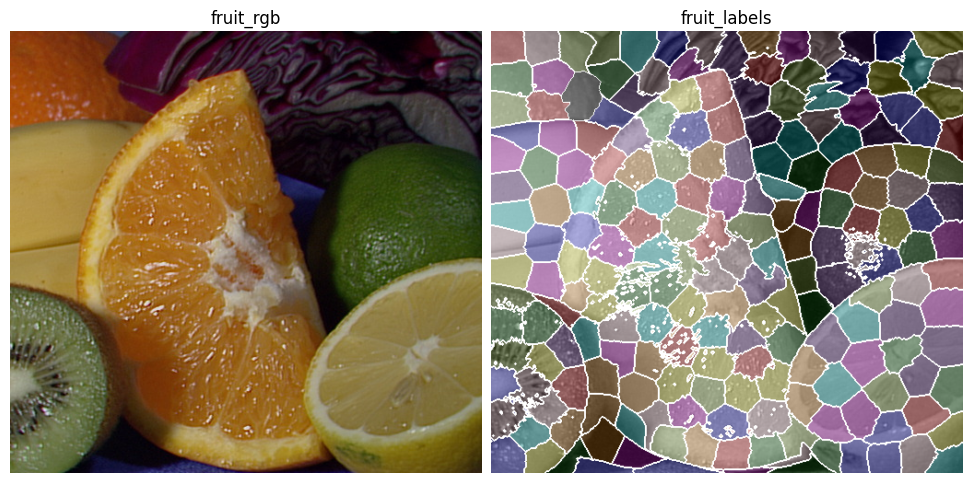

In [24]:
imshow_grid(fruit_rgb=fruit_rgb, fruit_labels=label2rgb(fruit_labels, fruit_rgb, alpha=0.2), vmax='max');

## Mean shift

# Watershed segmentation

<figure class="image">
  <img src="../figures/segmentation-watershed.png" alt="" style="width: 9.6in; background: white"/>
  <figcaption>
    Watershed algorithm example.<br>
  </figcaption>
</figure>

In [25]:
def watershed(image: np.ndarray, markers: np.ndarray | None = None) -> np.ndarray:
    """
    Computes the exact watershed lines using Meyer's Priority-Flood.
    
    Args:
        image: 2D array (float/int). ideally the Gradient Magnitude.
        markers: 2D array (int). 0 = unknown, >0 = region IDs.
        
    Returns:
        labels: 2D array. >0 = region IDs, -1 = watershed lines.
    """

    # 4-Connectivity (Up, Down, Left, Right) guarantees thin lines
    dx = [-1, 1, 0, 0]
    dy = [0, 0, -1, 1]

    def get_neighbors(x, y):
        for i in range(4):
            nx, ny = x + dx[i], y + dy[i]
            if 0 <= nx < height and 0 <= ny < width:
                yield nx, ny

    # We use a separate boolean mask to track what is in the queue
    # to avoid adding the same pixel multiple times.
    height, width = image.shape
    if markers is None:
        # Compute local minima as markers
        # A pixel is a local minimum if it's smaller than all its neighbors
        markers = np.zeros((height, width), dtype=np.int32)
        marker_id = 1
        for x in range(height):
            for y in range(width):
                is_local_min = True
                current_val = image[x, y]
                for nx, ny in get_neighbors(x, y):
                    if image[nx, ny] < current_val:
                        is_local_min = False
                        break
                if is_local_min:
                    markers[x, y] = marker_id
                    marker_id += 1
    labels = markers.copy()
    is_queued = np.zeros((height, width), dtype=bool)
    
    # Priority Queue: Stores tuples of (pixel_value, x, y)
    # Python's heapq is a Min-Heap, perfect for "steepest descent"
    pq = []

    # ----------------------
    # 1. INITIALIZATION
    # ----------------------
    # Scan for markers and add their empty neighbors to the queue
    for x in range(height):
        for y in range(width):
            if labels[x, y] > 0:  # If it's a marker
                for nx, ny in get_neighbors(x, y):
                    if labels[nx, ny] == 0 and not is_queued[nx, ny]:
                        # Add to PQ with priority = pixel intensity
                        heapq.heappush(pq, (image[nx, ny], nx, ny))
                        is_queued[nx, ny] = True

    # ----------------------
    # 2. THE FLOODING LOOP
    # ----------------------
    while pq:
        # Pop the pixel with the lowest intensity (steepest descent)
        val, x, y = heapq.heappop(pq)
        
        # Identify which distinct basins are neighbors to this pixel
        neighbor_labels = []
        for nx, ny in get_neighbors(x, y):
            l = labels[nx, ny]
            if l > 0: # If it belongs to a region
                neighbor_labels.append(l)
        
        # Get unique labels (remove duplicates)
        distinct_labels = list(set(neighbor_labels))
        
        if len(distinct_labels) == 1:
            # CASE A: Extension
            # All neighbors belong to the SAME basin.
            # Assign this pixel to that basin.
            labels[x, y] = distinct_labels[0]
            
            # Now add THIS pixel's unvisited neighbors to the queue
            for nx, ny in get_neighbors(x, y):
                if labels[nx, ny] == 0 and not is_queued[nx, ny]:
                    heapq.heappush(pq, (image[nx, ny], nx, ny))
                    is_queued[nx, ny] = True
                    
        elif len(distinct_labels) > 1:
            # CASE B: Conflict
            # Neighbors belong to DIFFERENT basins.
            # This pixel is a dam (Watershed Line).
            labels[x, y] = -1
            
            # CRITICAL: Do NOT add neighbors to queue. 
            # This stops the "dam" from growing thicker.

    return labels

In [26]:
coins2_gray = skimage.io.imread('../data/coins2.jpg', as_gray=True)
coins2_grad = (skimage.filters.sobel_h(coins2_gray) ** 2 + skimage.filters.sobel_v(coins2_gray) ** 2) ** 0.5
# coins_grad = skimage.morphology.dilation(coins_gray, skimage.morphology.disk(1)) - skimage.morphology.erosion(coins_gray, skimage.morphology.disk(1))
coins2_grad.shape, coins2_grad.dtype, coins2_grad.min(), coins2_grad.max()

((312, 252), dtype('float64'), np.float64(0.0), np.float64(0.6443700837228269))

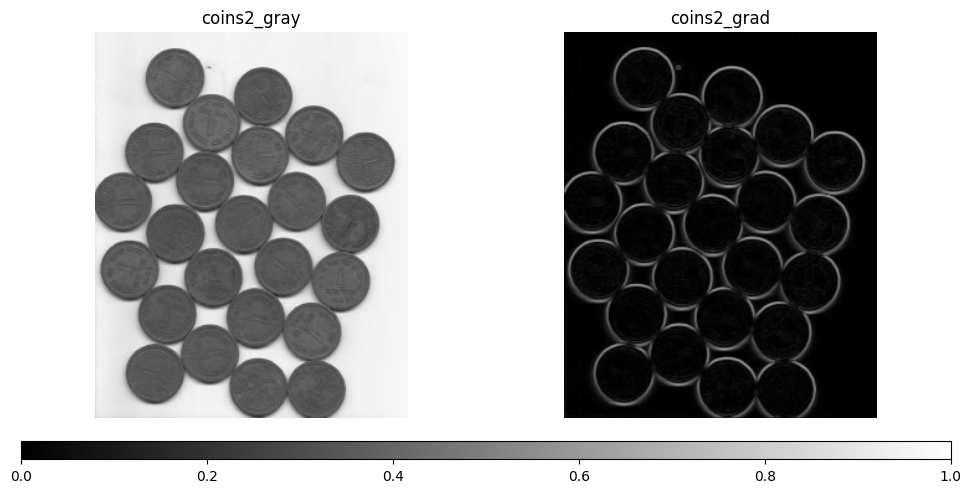

In [27]:
imshow_grid(coins2_gray=coins2_gray,coins2_grad=coins2_grad);

In [28]:
coins_labels_wshed = watershed(coins2_grad)
coins_labels_wshed.shape, coins_labels_wshed.dtype, coins_labels_wshed.min(), coins_labels_wshed.max()

((312, 252), dtype('int32'), np.int32(-1), np.int32(15045))

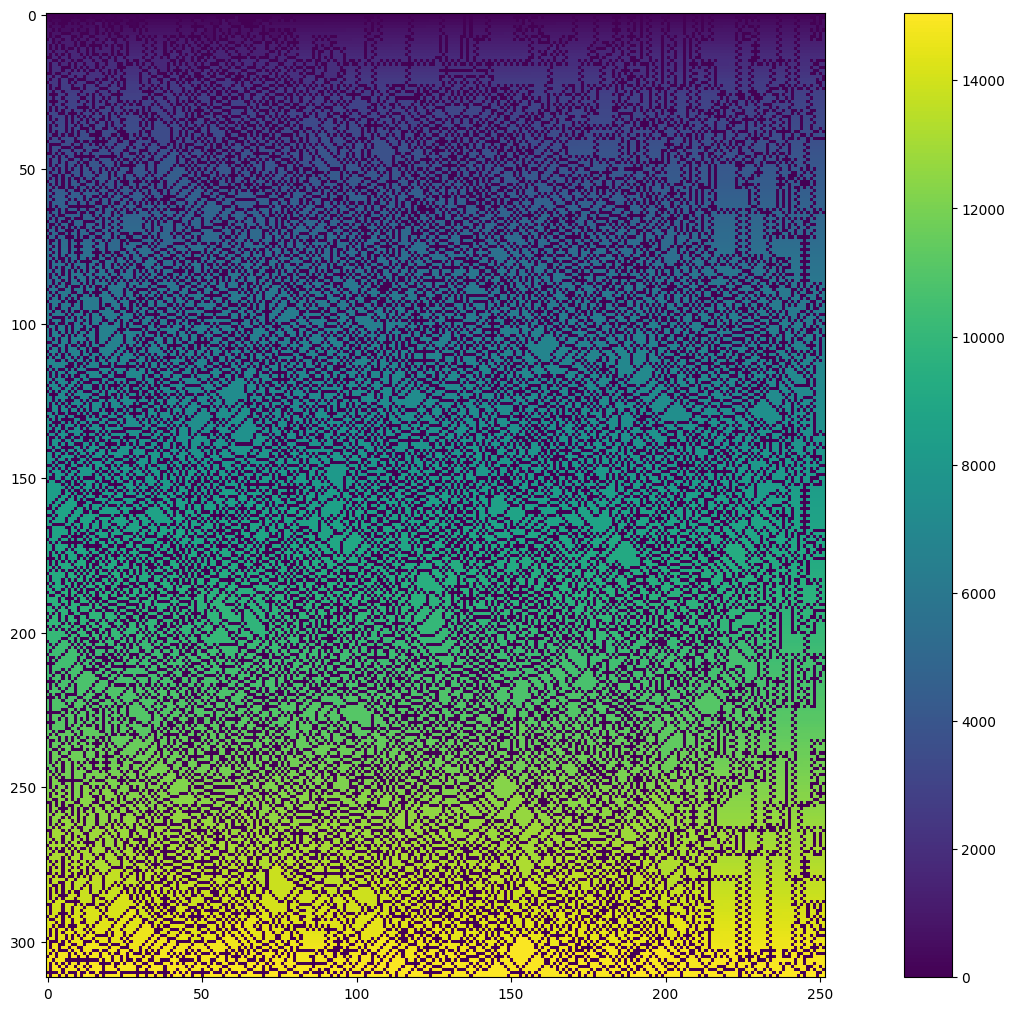

In [29]:
plt.figure(figsize=(16, 10))
# plt.imshow(label2rgb(coins_labels_wshed, coins_rgb));
plt.imshow(coins_labels_wshed);
plt.colorbar();

## Watershed markers

- In order to prevent oversegmentation, we can specify initial markers better than local minima of the gradient image.

In [30]:
coins2_bw = coins2_gray < 0.55
coins2_dist = scipy.ndimage.distance_transform_edt(coins2_bw)
coins2_dist.shape, coins2_dist.dtype, coins2_dist.min(), coins2_dist.max()

((312, 252), dtype('float64'), np.float64(0.0), np.float64(23.769728648009426))

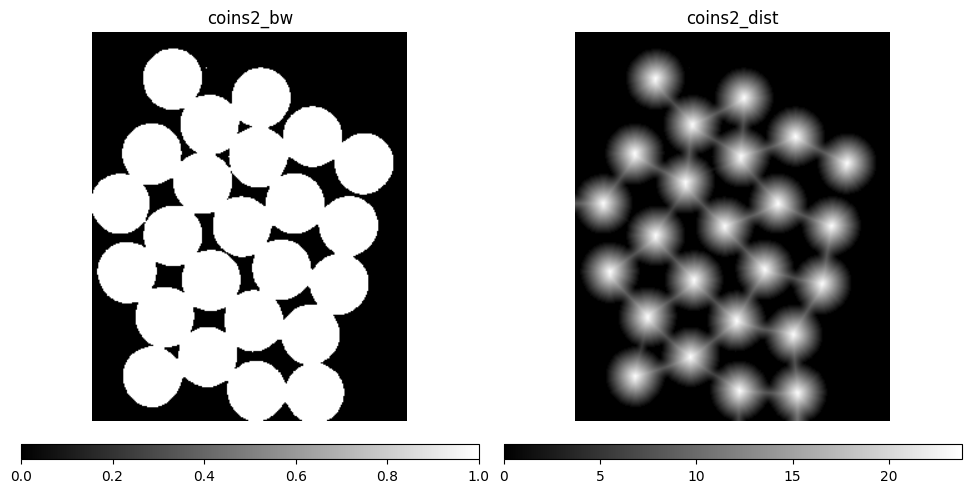

In [31]:
imshow_grid(coins2_bw=coins2_bw, coins2_dist=coins2_dist, vmax='max');

In [32]:
coins2_max_coords = skimage.feature.peak_local_max(coins2_dist, min_distance=5)
coins2_markers = np.zeros(coins2_bw.shape, dtype=int)
coins2_markers[25, 225] = 1
coins2_markers[coins2_max_coords[:, 0], coins2_max_coords[:, 1]] = 2 + np.arange(coins2_max_coords.shape[0])
coins2_max_coords.shape

(24, 2)

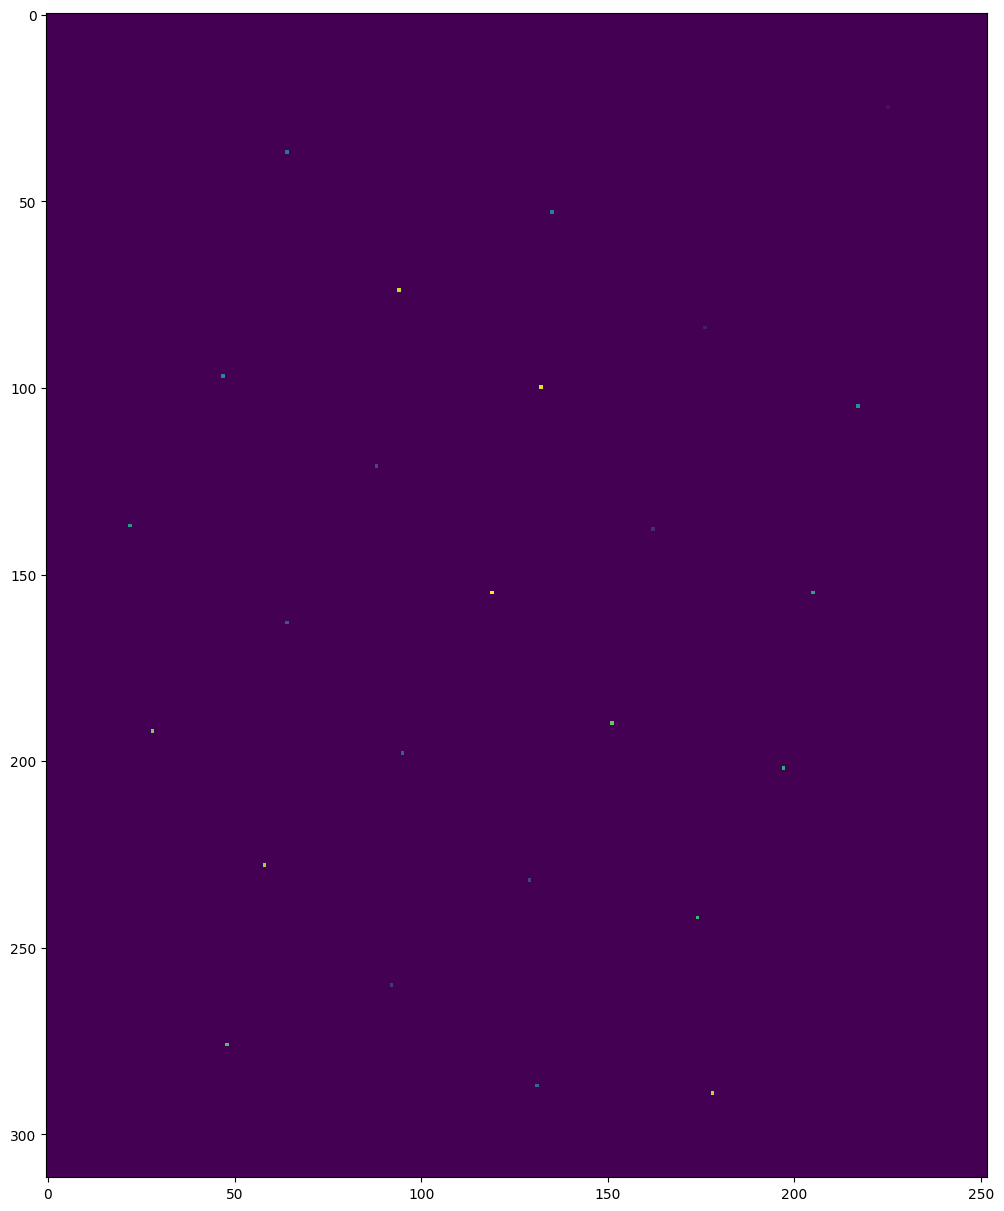

In [33]:
plt.figure(figsize=(12, 12))
plt.imshow(coins2_markers, cmap='viridis');

In [34]:
coins2_labels_wshed2 = watershed(-coins2_dist, coins2_markers)
coins2_labels_wshed2[~coins2_bw] = 0

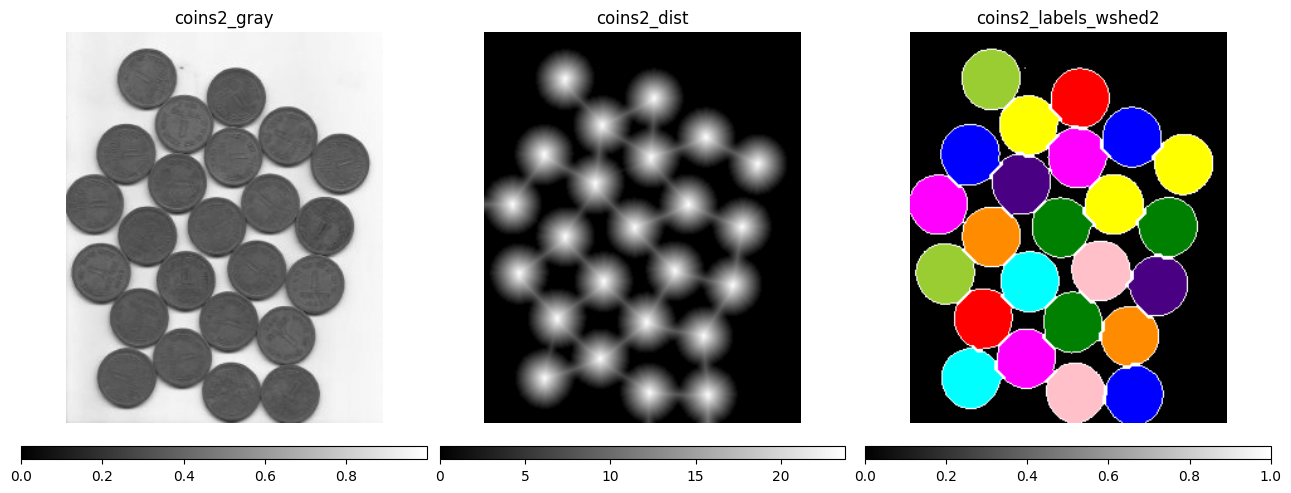

In [35]:
imshow_grid(coins2_gray=coins2_gray, coins2_dist=coins2_dist, coins2_labels_wshed2=label2rgb(coins2_labels_wshed2), vmax='max');

# Semi-supervised graph based segmentation using graph cuts

- A graph $G$ is a mathematical structure consisting of a set $V$ of *vertices (nodes)* and a set $E$ of *edges* connecting those vertices
  $$
  G = (V, E)
  $$
  where
  $$
  E \subseteq V \times V
  $$
- Edges can also have an associated *weights* and the set of all weights can be written as a matrix $\bold{W} = [w_{i,j}]$, where $w_{i,j}$ is the weight of the edge between nodes $v_i$ and $v_j$.
- If the graph is unoriented, the matrix $\bold{W}$ is symmetric, i.e. $w_{i,j} = w_{j,i}$.


<figure class="image">
  <img src="../figures/segmentation-image_as_graph.png" alt="" style="width: 6.4in; background: white"/>
  <figcaption>
    Image as a graph and an example segmentation.<br>
    Source: [Gonzalez18], Fig. 10.53
  </figcaption>
</figure>

**Image as a graph**
- Each pixel will be a vertex (node).
- Each pair of adjacent pixels $v_i$ and $v_j$ constitute an edge.
- The weight $w_{i,j}$ of the edge between $v_i$ and $v_j$ is a function of the *pixel similarity* between $v_i$ nd $v_j$, e.g.  
  $$
  w_{i,j} = \frac{ 1 }{ ||I(v_i) - I(v_j)|| + \epsilon }
  \qquad
  \text{or}
  \qquad
  w_{i,j} = \exp\left( -\frac{ ||I(v_i) - I(v_j)||^2 }{ 2\sigma^2 } \right)
  $$
  where
  - $I(v)$ is the value of the image at pixel associated with node $v$.

**Segmentation as the minimal graph cut**
- Graph cuts are usually applied for segmentation into foreground vs background.
- In order to assign pixels to either one of the classes, every node of the graph representing a pixel is also connected to two special nodes:
  - *source node ($S$)*, which represents e.g. background,
  - *sink node ($T$)*, which represents e.g. foreground.
- The weights of edges connecting $S$ and $T$ to other nodes are set as
  - $w_{S,i}$ is set to probability that node (pixel) $v_i$ belongs to the *background*,
  - $w_{T,i}$ is set to probability that node (pixel) $v_i$ belongs to the *foreground*.
  - These are *estimated* based e.g. on user input (GrabCut) or color models etc.
- Then we find the [**minimum cut (min-cut)**](https://en.wikipedia.org/wiki/Minimum_cut) of the graph that separates the source node $S$ from the sink node $T$ (i.e. there is no path from $S$ to $T$).
  - Min-cut will split the graph into two disjoint sub-graphs by removing edges with the lowest overall sum of weights.
  - Removing an edge connecting nodes with high weight (tow similar pixels) is *expensive*, so the method will tend to separate along brightness/color transitions (image edges).
  - Nodes (pixels) that remain connected to $S$ are labeled as background, and those that remain connected to $T$ are labeled as foreground.

<figure class="image">
  <img src="../figures/segmentation-graphcut.png" alt="" style="width: 6.4in; background: white"/>
  <figcaption>
    Image as a graph and an example segmentation.<br>
    Source: [Gonzalez18], Fig. 10.54
  </figcaption>
</figure>


## OpenCV GrabCut example

https://docs.opencv.org/4.x/d8/d83/tutorial_py_grabcut.html

### Using a bounding box estimate

- We'll create a rectangle representing *possible* foreground.
- Everything outside of the rectangle is *definitely* background.
- Based on foreground/background associtation of pixels, we can compute a probability distribution (or simply a histogram) that tells us what the probability of pixels belonging to either one of the classes is.
- We use these probabilities as weights of the edges connecting pixels to the special nodes $S$ and $T$.
- The GrabCut will segment the image into background and foreground using the min-cut algorithm.
- We can then take the result, re-initialize the background and foreground probability distributions and run GrabCut again.
- We repeat the above until convergence or for some number of iterations.

In [36]:
messi_rgb = cv.imread('../data/messi5.jpg')[..., ::-1]
messi_rect = 50, 50, 450, 290  # xywh

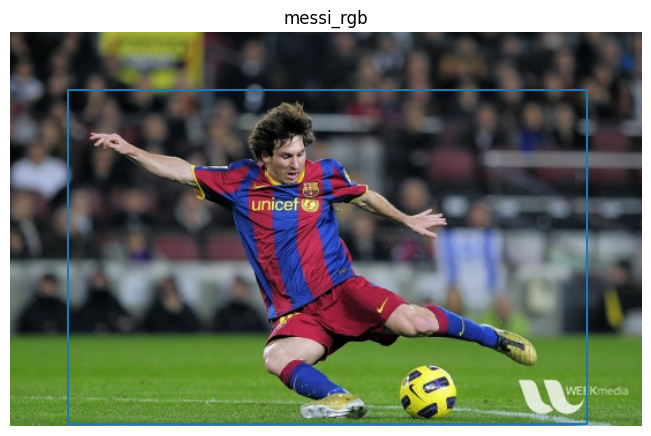

In [37]:
fig, axes = imshow_grid(messi_rgb=messi_rgb)
axes[0].plot(
    [messi_rect[0], messi_rect[0] + messi_rect[2], messi_rect[0] + messi_rect[2], messi_rect[0], messi_rect[0]],
    [messi_rect[1], messi_rect[1], messi_rect[1] + messi_rect[3], messi_rect[1] + messi_rect[3], messi_rect[1]],
);

In [38]:
messi_mask_m, messi_bg_mdl_m, messi_fg_mdl_m = cv.grabCut(
    messi_rgb,
    np.zeros(messi_rgb.shape[:2], dtype=np.uint8),
    messi_rect,
    np.zeros((1, 65), np.float64),  # background model computed internally
    np.zeros((1, 65), np.float64),  # foreground model computed internally
    5,
    mode=cv.GC_INIT_WITH_RECT,
)
messi_mask_m.shape, messi_mask_m.dtype, messi_mask_m.min(), messi_mask_m.max()

((342, 548), dtype('uint8'), np.uint8(0), np.uint8(3))

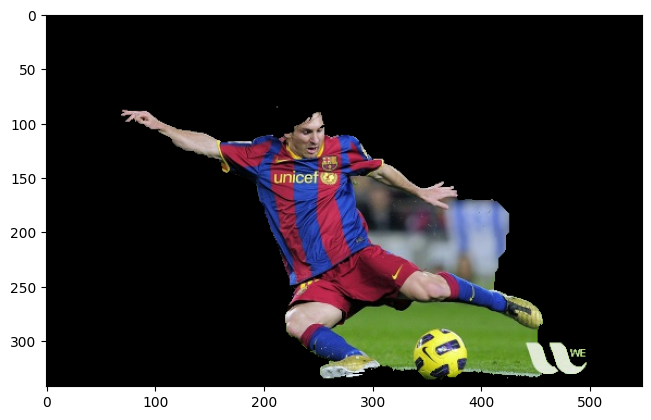

In [39]:
plt.imshow(((messi_mask_m == cv.GC_FGD) | (messi_mask_m == cv.GC_PR_FGD))[..., None] * messi_rgb);

### Using more precise markers

- We can make the initial background and foreground probability distribution estimates more accurate by specifying pixels more precisely.
- We'll draw the markers denoting background and foreground *manually* into the image.

In [40]:
messi_markers = cv.imread('../data/messi5_markers.png', cv.IMREAD_UNCHANGED)

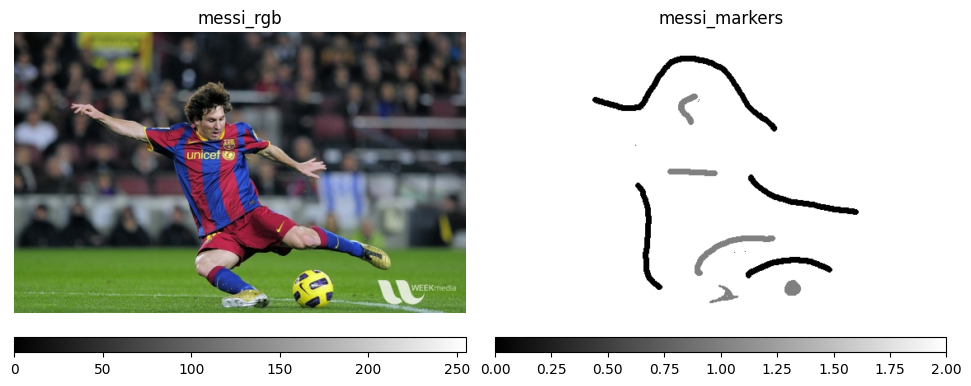

In [41]:
imshow_grid(messi_rgb=messi_rgb, messi_markers=messi_markers, vmax='max');

In [42]:
messi_mask_m, messi_bg_mdl_m, messi_fg_mdl_m = cv.grabCut(messi_rgb, messi_markers.copy(), None, None, None, 5, mode=cv.GC_INIT_WITH_MASK)

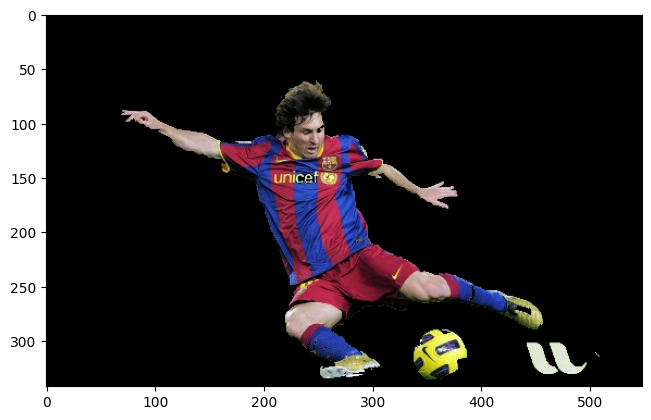

In [43]:
plt.imshow(((messi_mask_m == cv.GC_FGD) | (messi_mask_m == cv.GC_PR_FGD))[..., None] * messi_rgb);

# Deep learning based segmentation using Segment Anything Model 2 (SAM2)

<figure class="image">
  <img src="../figures/segmentation-tasks.png" alt="" style="width: 12.8in; background: white"/>
  <figcaption>
    Different segmentation tasks.<br>
  </figcaption>
</figure>

In [ ]:
# download sam2.1_hiera_tiny.pt from
# https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
sam2_model = sam2.build_sam.build_sam2(
    os.path.abspath('../data/sam2.1_hiera_t.yaml'),  # it wants it relative to sam2/build_sam.py file, which is god knows where
    '../data/sam2.1_hiera_tiny.pt',
    device='cpu',
)
predictor = sam2.sam2_image_predictor.SAM2ImagePredictor(sam2_model)
predictor

## Using few points

In [45]:
truck_rgb = skimage.io.imread('../data/truck.jpg')
truck_point = np.array([[500, 375]])
truck_label = np.array([1])

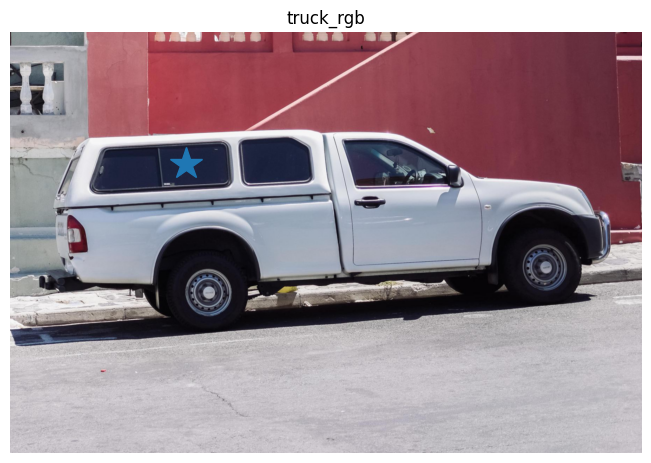

In [46]:
fig, axes = imshow_grid(truck_rgb=truck_rgb);
axes[0].plot(*truck_point.T, '*', markersize=24);

In [47]:
predictor.set_image(truck_rgb)
truck_masks, truck_scores, truck_logits = predictor.predict(
    point_coords=truck_point,
    point_labels=truck_label,
    multimask_output=True,
)
sorted_ind = np.argsort(truck_scores)[::-1]
truck_masks = truck_masks[sorted_ind]
truck_scores = truck_scores[sorted_ind]
truck_logits = truck_logits[sorted_ind]
truck_masks.shape, truck_scores.shape, truck_logits.shape

((3, 1200, 1800), (3,), (3, 256, 256))

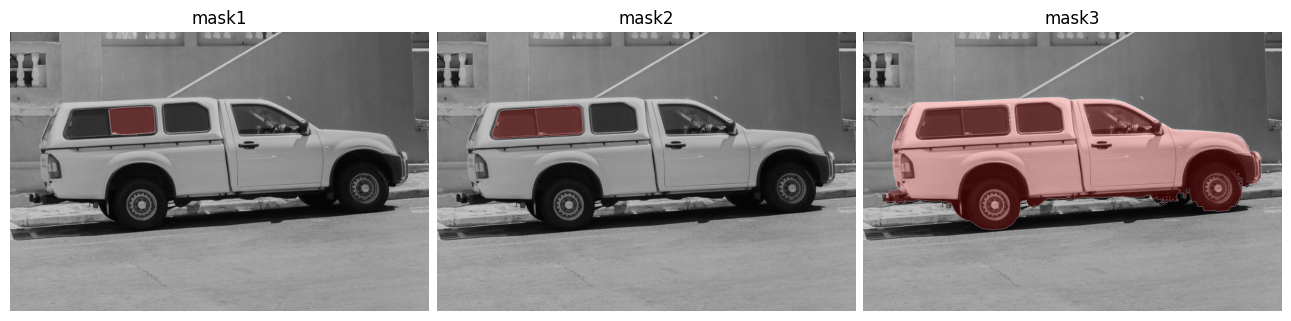

In [48]:
imshow_grid(mask1=label2rgb(truck_masks[0], truck_rgb), mask2=label2rgb(truck_masks[1], truck_rgb), mask3=label2rgb(truck_masks[2], truck_rgb));

## Using a bounding box

In [49]:
truck_box = np.array([100, 240, 1750, 850])
truck_mask_bb, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=truck_box[None, :],
    multimask_output=False,
)
truck_mask_bb = truck_mask_bb.squeeze()
truck_mask_bb.shape

(1200, 1800)

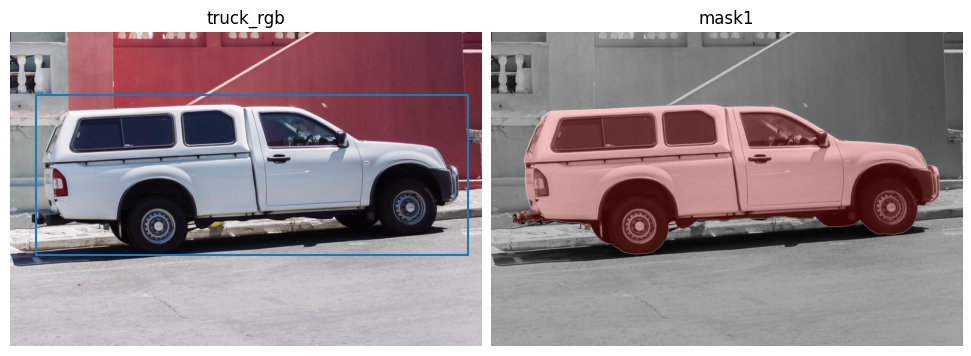

In [50]:
fig, axes = imshow_grid(truck_rgb=truck_rgb, mask1=label2rgb(truck_mask_bb, truck_rgb));
axes[0].plot([truck_box[0], truck_box[2], truck_box[2], truck_box[0], truck_box[0]], [truck_box[1], truck_box[1], truck_box[3], truck_box[3], truck_box[1]], '-');